# Comparativo de Classificadores com Validação Cruzada e Balanceamento

*Investigando se o desbalanceamento de classes explica o recall limitado na predição de renda acima de 50 mil dólares*

**Autor:** Wellington Moreira  
**Contato:** [LinkedIn](https://www.linkedin.com/in/wellington-moreira-santos/) | wsantos08@hotmail.com  
**Data:** Agosto de 2026 | **Versão:** 1.0  
**Dataset:** [Adult Census Income (UCI Machine Learning Repository)](https://uci.edu)  
**Licença:** [MIT](https://opensource.org) (Livre para uso acadêmico e comercial)

---
### Resumo Executivo
Este notebook apresenta um benchmark de algoritmos de classificação (ex: Regressão Logística, Random Forest, XGBoost) aplicados à predição de renda anual. O foco principal é avaliar o impacto de técnicas de balanceamento (como SMOTE ou undersampling) na métrica de **Recall** para a classe minoritária (>50k), utilizando validação cruzada estratificada para garantir a robustez dos resultados.


## 1. Imports e Configurações

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import session_info

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix, PrecisionRecallDisplay

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

from scipy.stats import wilcoxon

In [2]:
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#f1f5f9',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

pd.set_option('display.max_columns', None)

session_info.show(dependencies=False)

## 2. Coleta e Inspeção dos Dados

### 2.1 Visão Geral

In [4]:
# atributos
columns = [
    "Age",
    "Workclass",
    "Fnlwgt",
    "Education",
    "Education-Num",
    "Marital-Status",
    "Occupation",
    "Relationship",
    "Race",
    "Sex",
    "Capital-Gain",
    "Capital-Loss",
    "Hours-per-Week",
    "Native-Country",
    "Income",
]

# carga 
df = pd.read_csv('data/adult.data', names=columns)
df.head()

,Age,Workclass,Fnlwgt,Education,Education-Num,Marital-Status,Occupation,Relationship,Race,Sex,Capital-Gain,Capital-Loss,Hours-per-Week,Native-Country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# dimensao
df.shape

(32561, 15)

In [6]:
# tipos
df.dtypes

Age               int64
Workclass           str
Fnlwgt            int64
Education           str
Education-Num     int64
Marital-Status      str
Occupation          str
Relationship        str
Race                str
Sex                 str
Capital-Gain      int64
Capital-Loss      int64
Hours-per-Week    int64
Native-Country      str
Income              str
dtype: object

In [7]:
# nulos
df.isnull().sum()

Age               0
Workclass         0
Fnlwgt            0
Education         0
Education-Num     0
Marital-Status    0
Occupation        0
Relationship      0
Race              0
Sex               0
Capital-Gain      0
Capital-Loss      0
Hours-per-Week    0
Native-Country    0
Income            0
dtype: int64

datasets antigos costumam representar ausência de informação com um caractere no lugar de um valor nulo real.

In [10]:
# busca por dominio como nulo 
for col in df.select_dtypes(include='object').columns:
    print( col,(df[col].str.strip() == '?').sum() )

Workclass 1836
Education 0
Marital-Status 0
Occupation 1843
Relationship 0
Race 0
Sex 0
Native-Country 583
Income 0


O dataset tem 32561 registros e 15 colunas, sendo 6 numéricas e 9 categóricas, muitos registros contém atributos com dados ausentes mascarados com '?'.

### 2.2 Estatísticas Descritivas

In [11]:
df.describe()

,Age,Fnlwgt,Education-Num,Capital-Gain,Capital-Loss,Hours-per-Week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


A idade média é de aproximadamente 38,6 anos, com mínimo de 17 e máximo de 90. 

`capital-gain` e `capital-loos` têm médias muito baixas frente aos seus valores máximos (99999 e 4356, respectivamente), o que indica distribuições extremamente assimétricas, com a maioria dos registros em zero e poucos valores muito altos. 

`hour-per-week` tem média de 40,4 horas, consistente com jornada de trabalho padrão.

### 2.3 Distribuição da Variável Alvo

In [13]:
df['Income'].value_counts()

Income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [16]:
df['Income'].value_counts(normalize=True)

Income
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64

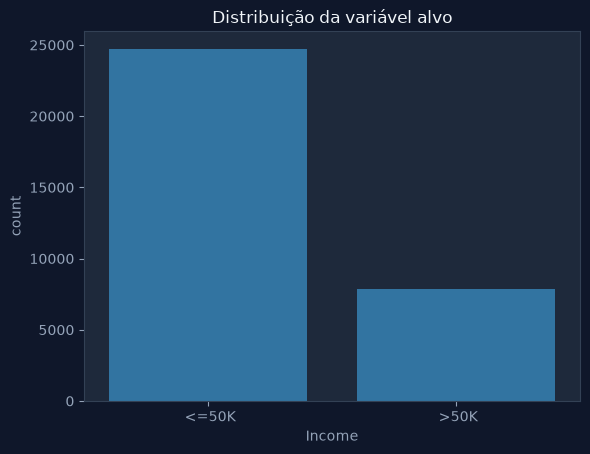

In [15]:
sns.countplot(x='Income', data=df)
plt.title('Distribuição da variável alvo')
plt.show()

A classe `<=50K` tem 24720 registros e a classe `>50K` tem 7841, uma proporção de aproximadamente 76% contra 24%. Esse desbalanceamento é o ponto de partida da pergunta central deste projeto.